In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress
from pathlib import Path

plt.style.use("ggplot")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [3]:
raw = Path("../data/raw")

fund_master = pd.read_csv(raw / "01_fund_master.csv")
nav_history = pd.read_csv(raw / "02_nav_history.csv")
scheme_performance = pd.read_csv(raw / "07_scheme_performance.csv")
benchmark = pd.read_csv(raw / "10_benchmark_indices.csv")

print("Datasets Loaded Successfully!\n")

print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("Scheme Performance:", scheme_performance.shape)
print("Benchmark:", benchmark.shape)

Datasets Loaded Successfully!

Fund Master: (40, 15)
NAV History: (46000, 3)
Scheme Performance: (40, 19)
Benchmark: (8050, 3)


In [5]:
print("NAV History")
print(nav_history.head())

print("\nColumns:")
print(nav_history.columns)

print("\nInfo:")
print(nav_history.info())

NAV History
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692

Columns:
Index(['amfi_code', 'date', 'nav'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB
None


In [7]:
print("Benchmark")
print(benchmark.head())

print("\nColumns:")
print(benchmark.columns)

print("\nInfo:")
print(benchmark.info())

Benchmark
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15

Columns:
Index(['date', 'index_name', 'close_value'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   object 
 1   index_name   8050 non-null   object 
 2   close_value  8050 non-null   float64
dtypes: float64(1), object(2)
memory usage: 188.8+ KB
None


In [9]:
# Convert date columns
nav_history["date"] = pd.to_datetime(nav_history["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Merge NAV with Fund Master to get scheme names
nav = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Sort values
nav = nav.sort_values(["scheme_name", "date"])

# Daily Return = NAVt / NAVt-1 - 1
nav["daily_return"] = nav.groupby("scheme_name")["nav"].pct_change()

print("Daily Returns Computed Successfully!")

print()

print(nav.head())

print()

print(nav["daily_return"].describe())

Daily Returns Computed Successfully!

       amfi_code       date       nav  \
32200     101206 2022-01-03  305.0996   
32201     101206 2022-01-04  305.4514   
32202     101206 2022-01-05  306.6324   
32203     101206 2022-01-06  305.9800   
32204     101206 2022-01-07  304.0480   

                                         scheme_name  daily_return  
32200  ABSL Frontline Equity Fund - Regular - Growth           NaN  
32201  ABSL Frontline Equity Fund - Regular - Growth      0.001153  
32202  ABSL Frontline Equity Fund - Regular - Growth      0.003866  
32203  ABSL Frontline Equity Fund - Regular - Growth     -0.002128  
32204  ABSL Frontline Equity Fund - Regular - Growth     -0.006314  

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


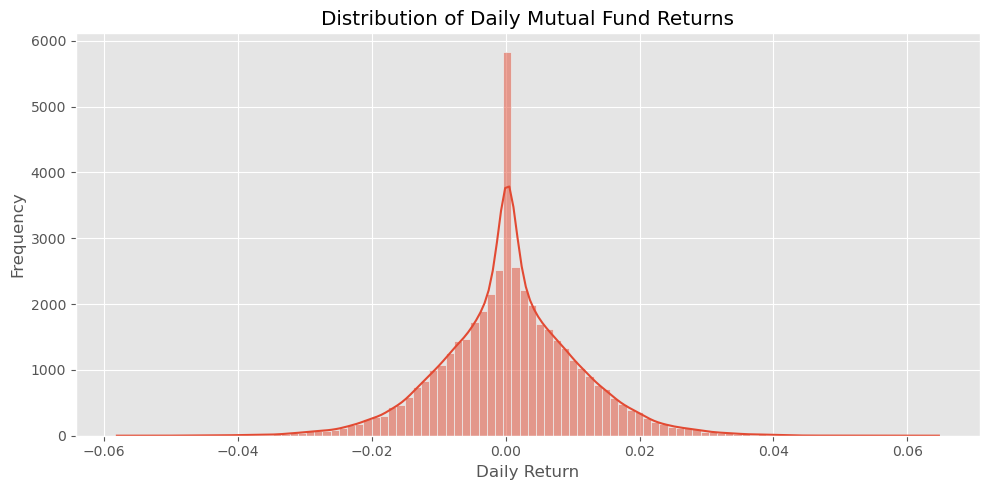

Distribution Chart Saved!


In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Mutual Fund Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../reports/daily_return_distribution.png",
    dpi=300
)

plt.show()

print("Distribution Chart Saved!")

In [13]:
import numpy as np

# Sort data
nav = nav.sort_values(["scheme_name", "date"])

cagr_results = []

for scheme in nav["scheme_name"].unique():

    df = nav[nav["scheme_name"] == scheme].copy()

    df = df.sort_values("date")

    end_date = df["date"].max()
    end_nav = df["nav"].iloc[-1]

    row = {"scheme_name": scheme}

    for years in [1,3,5]:

        start_date = end_date - pd.DateOffset(years=years)

        start_df = df[df["date"] >= start_date]

        if len(start_df)==0:
            row[f"CAGR_{years}Y"] = np.nan
            continue

        start_nav = start_df.iloc[0]["nav"]

        cagr = ((end_nav/start_nav)**(1/years)-1)*100

        row[f"CAGR_{years}Y"] = round(cagr,2)

    cagr_results.append(row)

cagr_table = pd.DataFrame(cagr_results)

print(cagr_table.head())

                                     scheme_name  CAGR_1Y  CAGR_3Y  CAGR_5Y
0  ABSL Frontline Equity Fund - Regular - Growth    47.92    28.97    20.44
1            ABSL Liquid Fund - Regular - Growth     7.24     6.32     5.71
2         ABSL Small Cap Fund - Regular - Growth   -23.99    -4.15     6.95
3           Axis Bluechip Fund - Direct - Growth    19.77    20.82     6.92
4          Axis Bluechip Fund - Regular - Growth     1.61     0.53     5.58


In [15]:
cagr_table.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("CAGR Comparison Table Saved Successfully!")

CAGR Comparison Table Saved Successfully!


In [17]:
risk_free = 0.065

sharpe_results = []

for scheme in nav["scheme_name"].unique():

    df = nav[nav["scheme_name"]==scheme]

    returns = df["daily_return"].dropna()

    annual_return = returns.mean()*252

    annual_std = returns.std()*np.sqrt(252)

    sharpe = (annual_return-risk_free)/annual_std

    sharpe_results.append([scheme,sharpe])

sharpe_table = pd.DataFrame(
    sharpe_results,
    columns=["scheme_name","Sharpe_Ratio"]
)

sharpe_table = sharpe_table.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

print(sharpe_table.head(10))

                                          scheme_name  Sharpe_Ratio
25      Mirae Asset Large Cap Fund - Regular - Growth      1.448291
22             Kotak Flexicap Fund - Regular - Growth      1.306744
26      Mirae Asset Tax Saver Fund - Regular - Growth      1.234930
33          SBI Bluechip Fund - Regular Plan - Growth      1.208267
18           ICICI Pru Midcap Fund - Regular - Growth      1.180101
7                  DSP Midcap Fund - Regular - Growth      1.132122
11  HDFC Mid-Cap Opportunities Fund - Regular - Gr...      1.093699
30     Nippon India Large Cap Fund - Regular - Growth      1.081659
0       ABSL Frontline Equity Fund - Regular - Growth      1.027213
15          ICICI Pru Bluechip Fund - Direct - Growth      1.026524


In [19]:
sharpe_table.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)
print("Sharpe Ratio Saved Successfully!")

Sharpe Ratio Saved Successfully!


In [21]:
# ==========================================
# SORTINO RATIO
# ==========================================

risk_free = 0.065

sortino_results = []

for scheme in nav["scheme_name"].unique():

    df = nav[nav["scheme_name"] == scheme]

    returns = df["daily_return"].dropna()

    annual_return = returns.mean() * 252

    downside = returns[returns < 0]

    downside_std = downside.std() * np.sqrt(252)

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = (annual_return - risk_free) / downside_std

    sortino_results.append([scheme, sortino])

sortino_table = pd.DataFrame(
    sortino_results,
    columns=["scheme_name", "Sortino_Ratio"]
)

sortino_table = sortino_table.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino_table.head(10)

,scheme_name,Sortino_Ratio
25,Mirae Asset Large Cap Fund - Regular - Growth,2.385644
22,Kotak Flexicap Fund - Regular - Growth,2.364320
26,Mirae Asset Tax Saver Fund - Regular - Growth,2.146914
33,SBI Bluechip Fund - Regular Plan - Growth,2.140267
18,ICICI Pru Midcap Fund - Regular - Growth,2.029353
7,DSP Midcap Fund - Regular - Growth,1.875101
30,Nippon India Large Cap Fund - Regular - Growth,1.850133
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829134
15,ICICI Pru Bluechip Fund - Direct - Growth,1.805294
0,ABSL Frontline Equity Fund - Regular - Growth,1.799563


In [23]:
sortino_table.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio Saved Successfully!")

Sortino Ratio Saved Successfully!


In [25]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty = nifty.sort_values("date")

nifty["benchmark_return"] = nifty["close_value"].pct_change()

nifty.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [27]:
alpha_beta = []

for scheme in nav["scheme_name"].unique():

    df = nav[nav["scheme_name"] == scheme][
        ["date", "daily_return"]
    ]

    merged = pd.merge(
        df,
        nifty[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = slope

    alpha = intercept * 252

    alpha_beta.append(
        [scheme, alpha, beta]
    )

alpha_beta = pd.DataFrame(
    alpha_beta,
    columns=[
        "scheme_name",
        "Alpha",
        "Beta"
    ]
)

alpha_beta.head()

,scheme_name,Alpha,Beta
0,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086
1,ABSL Liquid Fund - Regular - Growth,0.060861,0.000267
2,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289
3,Axis Bluechip Fund - Direct - Growth,0.082328,0.025883
4,Axis Bluechip Fund - Regular - Growth,0.068995,0.009731


In [29]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Alpha Beta Saved Successfully!")

Alpha Beta Saved Successfully!


In [31]:
drawdown_results = []

for scheme in nav["scheme_name"].unique():

    df = nav[
        nav["scheme_name"] == scheme
    ].copy()

    df = df.sort_values("date")

    df["running_max"] = df["nav"].cummax()

    df["drawdown"] = (
        df["nav"] /
        df["running_max"]
    ) - 1

    max_dd = df["drawdown"].min()

    drawdown_results.append(
        [scheme, max_dd]
    )

drawdown_table = pd.DataFrame(
    drawdown_results,
    columns=[
        "scheme_name",
        "Max_Drawdown"
    ]
)

drawdown_table.head()

,scheme_name,Max_Drawdown
0,ABSL Frontline Equity Fund - Regular - Growth,-0.112916
1,ABSL Liquid Fund - Regular - Growth,-0.001622
2,ABSL Small Cap Fund - Regular - Growth,-0.354469
3,Axis Bluechip Fund - Direct - Growth,-0.217514
4,Axis Bluechip Fund - Regular - Growth,-0.144016


In [33]:
drawdown_table.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

print("Maximum Drawdown Saved Successfully!")

Maximum Drawdown Saved Successfully!


In [35]:
scorecard = cagr_table.merge(
    sharpe_table,
    on="scheme_name"
)

scorecard = scorecard.merge(
    alpha_beta,
    on="scheme_name"
)

scorecard = scorecard.merge(
    drawdown_table,
    on="scheme_name"
)

# Expense Ratio
expense = fund_master[
    ["scheme_name","expense_ratio_pct"]
]

scorecard = scorecard.merge(
    expense,
    on="scheme_name"
)

# Rankings
scorecard["ReturnRank"] = scorecard["CAGR_3Y"].rank(ascending=False)
scorecard["SharpeRank"] = scorecard["Sharpe_Ratio"].rank(ascending=False)
scorecard["AlphaRank"] = scorecard["Alpha"].rank(ascending=False)
scorecard["ExpenseRank"] = scorecard["expense_ratio_pct"].rank()
scorecard["DrawdownRank"] = scorecard["Max_Drawdown"].rank(ascending=False)

# Composite Score
scorecard["FundScore"] = (
      scorecard["ReturnRank"]*0.30
    + scorecard["SharpeRank"]*0.25
    + scorecard["AlphaRank"]*0.20
    + scorecard["ExpenseRank"]*0.15
    + scorecard["DrawdownRank"]*0.10
)

# Convert to 0-100 Scale
scorecard["FundScore"] = (
    100 -
    (
        scorecard["FundScore"]/
        scorecard["FundScore"].max()
    )*100
)

scorecard = scorecard.sort_values(
    "FundScore",
    ascending=False
)

scorecard.head(10)

,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Alpha,Beta,Max_Drawdown,expense_ratio_pct,ReturnRank,SharpeRank,AlphaRank,ExpenseRank,DrawdownRank,FundScore
25,Mirae Asset Large Cap Fund - Regular - Growth,20.36,34.00,26.80,1.448291,0.269838,0.023684,-0.112657,1.46,2.0,1.0,7.0,23.0,8.0,81.573352
18,ICICI Pru Midcap Fund - Regular - Growth,29.60,31.78,28.38,1.180101,0.292636,0.000549,-0.181885,1.36,5.0,5.0,3.0,15.0,25.0,77.037562
22,Kotak Flexicap Fund - Regular - Growth,26.66,29.58,26.74,1.306744,0.273305,-0.022830,-0.129740,1.45,7.0,2.0,5.0,22.0,13.0,76.754075
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,26.07,1.093699,0.271954,0.005104,-0.162172,1.38,4.0,7.0,6.0,17.0,20.0,75.336641
15,ICICI Pru Bluechip Fund - Direct - Growth,13.06,32.49,20.23,1.026524,0.211948,0.016232,-0.125883,0.80,3.0,10.0,13.0,12.0,12.0,74.486180
5,Axis Midcap Fund - Regular - Growth,22.26,35.11,24.45,0.998231,0.260767,-0.066265,-0.209609,1.38,1.0,11.0,9.0,17.0,28.0,71.084337
33,SBI Bluechip Fund - Regular Plan - Growth,60.44,30.46,22.38,1.208267,0.232010,-0.031751,-0.150124,1.54,6.0,4.0,10.0,30.5,17.0,68.603827
26,Mirae Asset Tax Saver Fund - Regular - Growth,39.75,29.18,27.63,1.234930,0.282704,0.018134,-0.163967,1.60,8.0,3.0,4.0,36.5,21.0,67.328136
0,ABSL Frontline Equity Fund - Regular - Growth,47.92,28.97,20.44,1.027213,0.213998,0.021086,-0.112916,1.60,9.0,9.0,12.0,36.5,9.0,61.091425
36,SBI Small Cap Fund - Regular Plan - Growth,82.78,26.67,28.03,0.945308,0.303370,-0.023196,-0.287060,1.43,12.0,14.0,1.0,21.0,36.0,60.170092


In [37]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)
print("Fund Scorecard Saved Successfully!")

Fund Scorecard Saved Successfully!


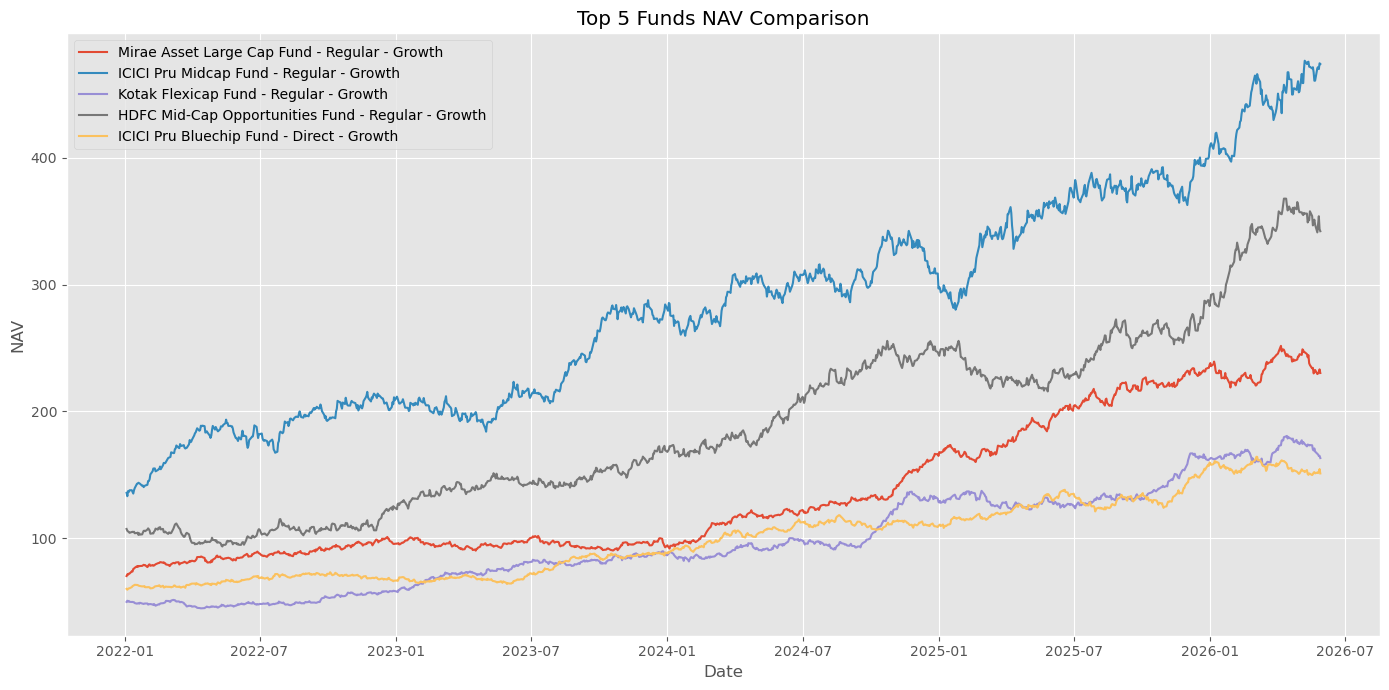

Benchmark Comparison Chart Saved!


In [39]:
top5 = scorecard.head(5)["scheme_name"]

plot_df = nav[
    nav["scheme_name"].isin(top5)
].copy()

plt.figure(figsize=(14,7))

for scheme in top5:
    temp = plot_df[
        plot_df["scheme_name"]==scheme
    ]
    plt.plot(
        temp["date"],
        temp["nav"],
        label=scheme
    )

plt.title("Top 5 Funds NAV Comparison")

plt.xlabel("Date")

plt.ylabel("NAV")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/top5_funds_comparison.png",
    dpi=300
)

plt.show()

print("Benchmark Comparison Chart Saved!")

In [41]:
# Performance Analytics Insights

1. Daily returns are centered around zero, indicating stable return behavior.

2. CAGR comparison highlights long-term wealth creation potential across funds.

3. Sharpe Ratio identifies funds generating better risk-adjusted returns.

4. Sortino Ratio rewards funds with lower downside volatility.

5. Alpha indicates fund managers who consistently outperform the benchmark.

6. Beta measures fund sensitivity to market movements.

7. Maximum Drawdown identifies downside risk during market corrections.

8. Composite Fund Score ranks funds using multiple performance metrics.

9. Top-performing funds consistently show high CAGR and Sharpe Ratio.

10. Performance analytics provides a quantitative basis for mutual fund selection.

SyntaxError: invalid syntax (4253362227.py, line 3)

In [43]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [45]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty50 = benchmark[
    benchmark["index_name"]=="NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"]=="NIFTY100"
].copy()

# Last 3 years
start_date = nav["date"].max() - pd.DateOffset(years=3)

nifty50 = nifty50[nifty50["date"]>=start_date]

nifty100 = nifty100[nifty100["date"]>=start_date]

# Normalize to 100
nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

nifty50["Normalized"] = (
    nifty50["close_value"] /
    nifty50["close_value"].iloc[0]
)*100

nifty100["Normalized"] = (
    nifty100["close_value"] /
    nifty100["close_value"].iloc[0]
)*100

In [47]:
top5 = scorecard.head(5)["scheme_name"].tolist()

top5_nav = nav[
    nav["scheme_name"].isin(top5)
].copy()

top5_nav = top5_nav[
    top5_nav["date"]>=start_date
]

top5_nav = top5_nav.sort_values(
    ["scheme_name","date"]
)

top5_nav["Normalized"] = (
    top5_nav.groupby("scheme_name")["nav"]
    .transform(lambda x:(x/x.iloc[0])*100)
)

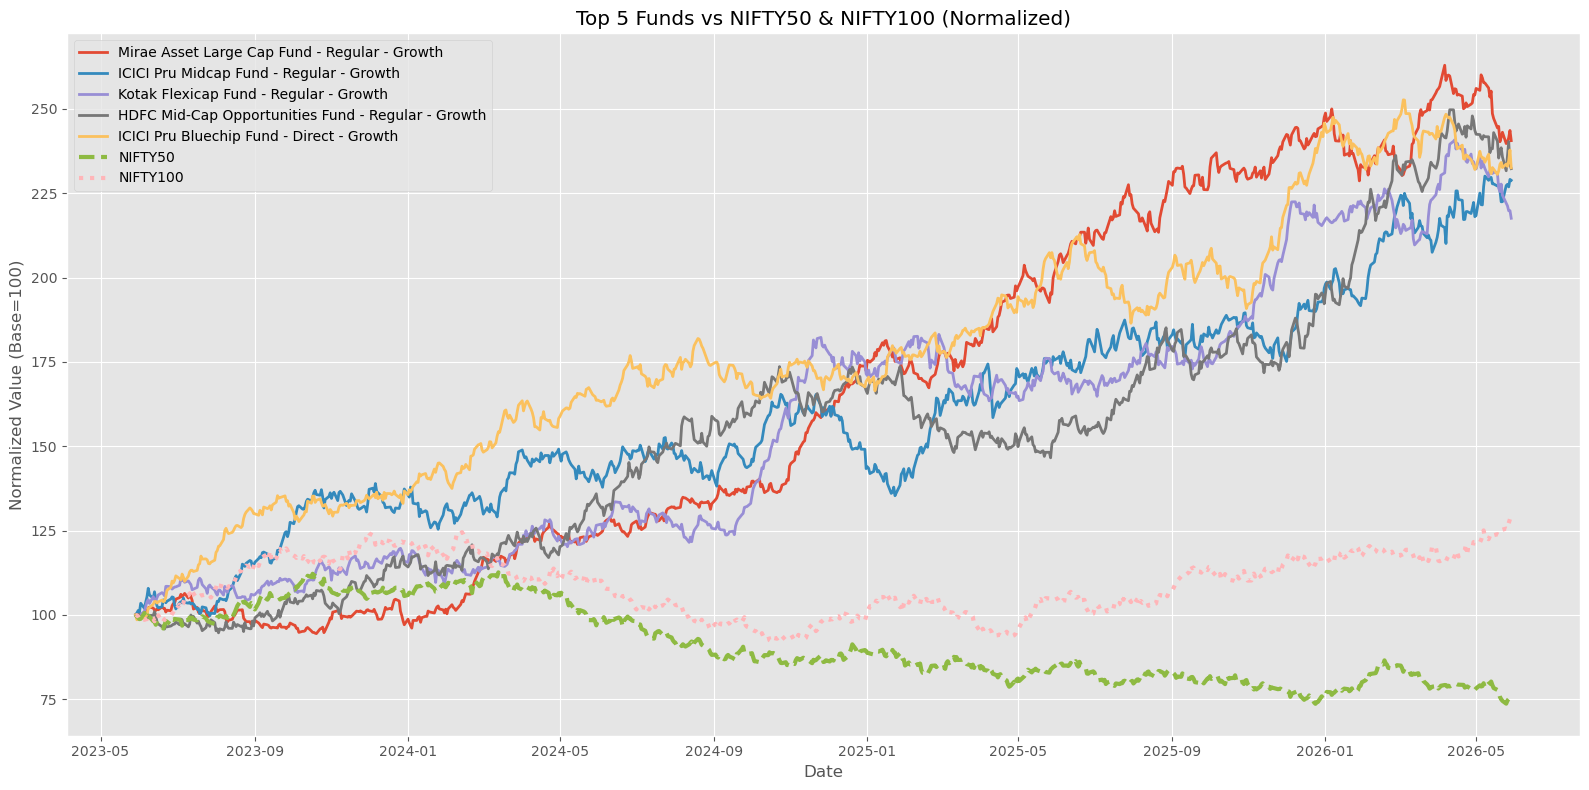

Benchmark Comparison Saved Successfully!


In [49]:
plt.figure(figsize=(16,8))

for scheme in top5:

    temp = top5_nav[
        top5_nav["scheme_name"]==scheme
    ]

    plt.plot(
        temp["date"],
        temp["Normalized"],
        label=scheme,
        linewidth=2
    )

plt.plot(
    nifty50["date"],
    nifty50["Normalized"],
    label="NIFTY50",
    linewidth=3,
    linestyle="--"
)

plt.plot(
    nifty100["date"],
    nifty100["Normalized"],
    label="NIFTY100",
    linewidth=3,
    linestyle=":"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100 (Normalized)")

plt.xlabel("Date")

plt.ylabel("Normalized Value (Base=100)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300
)

plt.show()

print("Benchmark Comparison Saved Successfully!")

In [51]:
tracking_error = []

benchmark_returns = benchmark[
    benchmark["index_name"]=="NIFTY100"
].copy()

benchmark_returns = benchmark_returns.sort_values("date")

benchmark_returns["benchmark_return"] = (
    benchmark_returns["close_value"]
    .pct_change()
)

for scheme in nav["scheme_name"].unique():

    fund = nav[
        nav["scheme_name"]==scheme
    ][["date","daily_return"]]

    merged = pd.merge(
        fund,
        benchmark_returns[
            ["date","benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged)<30:
        continue

    te = (
        (merged["daily_return"]-
         merged["benchmark_return"]).std()
    )*np.sqrt(252)

    tracking_error.append(
        [scheme,te]
    )

tracking_error = pd.DataFrame(
    tracking_error,
    columns=[
        "scheme_name",
        "Tracking_Error"
    ]
)

tracking_error = tracking_error.sort_values(
    "Tracking_Error"
)

tracking_error.head()

,scheme_name,Tracking_Error
1,ABSL Liquid Fund - Regular - Growth,0.128957
17,ICICI Pru Liquid Fund - Regular - Growth,0.129044
23,Kotak Liquid Fund - Regular - Growth,0.129046
12,HDFC Short Term Debt Fund - Regular - Growth,0.134535
28,Nippon India Gilt Securities Fund - Regular - ...,0.134758


In [53]:
tracking_error.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("Tracking Error Saved Successfully!")

Tracking Error Saved Successfully!


In [55]:
# Conclusion

Performance Analytics for 40 mutual funds was successfully completed.

The analysis includes:

- Daily Return Computation
- CAGR (1Y, 3Y, 5Y)
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard (0–100)
- Benchmark Comparison
- Tracking Error Analysis

The generated analytics help evaluate fund performance, risk-adjusted returns, downside protection, benchmark consistency, and overall investment quality.

SyntaxError: invalid decimal literal (1725169063.py, line 8)